In [2]:
import pandas as pd
import numpy as np

file_path = 'input_data/Source File 4-19.xlsx'

sheet_names = [
    "EDFT",
    "TH Summary",
    "TH Hourly",
    "ML Store",
    "Emp List",
    "Apr Unapr OT",
    "Check Pivot",
    "Current Week OT",
    "Sheet10",
    "SCH",
    "SCH for MO"
]

dfs = {}

for sheet in sheet_names:
    dfs[sheet] = pd.read_excel(file_path, sheet_name=sheet)



d:\Program Files\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell X3100 is marked as a date but the serial value 3120000 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
d:\Program Files\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell X3521 is marked as a date but the serial value 7150000 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
d:\Program Files\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell S18505 is marked as a date but the serial value 2102692565 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
d:\Program Files\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell S23019 is marked as a date but the serial value 7856725593 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
d:\Program Files\Python311\Lib\site-packages\ope

In [3]:
import time
# Access example:
df_edft = dfs["EDFT"]
df_th_summary = dfs["TH Summary"]
df_th_hourly = dfs["TH Hourly"]
df_ml_store = dfs["ML Store"]
# df_edft.head(10)


# ----------------------------
# PREP DATA
# ----------------------------
prep_start = time.time()
df = df_th_hourly.copy()

df_th_hourly["Date"] = pd.to_datetime(df_th_hourly["Date"], errors="coerce")
df_th_hourly["Hours"] = pd.to_numeric(df_th_hourly["Hours"], errors="coerce")



In [4]:
# Join TH Hourly with ML Store on Dist Department Code = Unique ID (case-insensitive)
# Create lowercase versions for matching
df_th_hourly["Dist Dept Code Lower"] = df_th_hourly["Dist Department Code"].astype(str).str.lower()
df_ml_store["Unique ID Lower"] = df_ml_store["Unique ID"].astype(str).str.lower()

df_th_hourly_joined = df_th_hourly.merge(
    df_ml_store,
    left_on="Dist Dept Code Lower",
    right_on="Unique ID Lower",
    how="left"
)

# Drop the lowercase columns after join
df_th_hourly_joined = df_th_hourly_joined.drop(columns=["Dist Dept Code Lower", "Unique ID Lower"])

# Filter only Pay Group = ML
df_th_hourly_joined_ml = df_th_hourly_joined[df_th_hourly_joined["Pay Group"] == "ML"]

df_th_hourly_joined_ml.to_csv("output_data/th_hourly_joined_ml.csv", index=False)

print(f"Original TH Hourly rows: {len(df_th_hourly)}")
print(f"After join & filter (ML only): {len(df_th_hourly_joined_ml)}")
print(f"Matched rows: {df_th_hourly_joined_ml['Unique ID'].notna().sum()}")
print("\nJoined columns:", df_th_hourly_joined_ml.columns.tolist())

Original TH Hourly rows: 17865
After join & filter (ML only): 14556
Matched rows: 14556

Joined columns: ['EE Code', 'Key', 'Employee_Name', 'Position_Title', 'UID', 'Pay Group', 'Employee_Status', 'DOL_Status', 'Pay_Type', 'Hire/Rehire Date', 'Home Department Code', 'Home Department Desc', 'Dist Department Code', 'Dist Department Desc', 'Day', 'Date', 'Earning Code', 'Earning Desc', 'Hours', 'Unique ID', 'Market Name', 'Store', 'SD Name', 'TM Name', 'HRBP / HRG', 'Tier', 'SOM Name', 'Store Contact', 'SOL Name']


In [5]:
# # Employee daily hours report (pivot: EE Code, Employee_Name as rows, Dates as columns)
# employee_daily_pivot = df_th_hourly_joined_ml.pivot_table(
#     index=["EE Code", "Employee_Name"],
#     columns="Date",
#     values="Hours",
#     aggfunc="sum",
#     fill_value=0
# )

# # Optional: Format date columns
# # employee_daily_pivot.columns = employee_daily_pivot.columns.strftime("%d-%b-%Y")

# # Add total hours column
# employee_daily_pivot["Total Hours"] = employee_daily_pivot.sum(axis=1)

# # Save to CSV
# employee_daily_pivot.to_csv("output_data/employee_daily_hours_pivot.csv")

# # Show sample
# employee_daily_pivot.head()

In [7]:
import copy 

# Make a DEEP copy of df_th_hourly_joined_ml
df_th_hourly_copy = copy.deepcopy(df_th_hourly_joined_ml)

# Get actual min and max dates from data
min_date = df_th_hourly_copy["Date"].min()
max_date = df_th_hourly_copy["Date"].max()

# Add week column (Wednesday to Tuesday week)
df_th_hourly_copy["Week_Start"] = df_th_hourly_copy["Date"] - pd.to_timedelta(
    (df_th_hourly_copy["Date"].dt.weekday - 2) % 7, unit='D'
)
df_th_hourly_copy["Week_End"] = df_th_hourly_copy["Week_Start"] + pd.Timedelta(days=6)

# Adjust first week: if Week_Start is before min_date, use min_date
first_week_start = df_th_hourly_copy["Week_Start"].min()
if first_week_start < min_date:
    df_th_hourly_copy.loc[df_th_hourly_copy["Week_Start"] == first_week_start, "Week_Start"] = min_date
    df_th_hourly_copy.loc[df_th_hourly_copy["Week_Start"] == first_week_start, "Week_End"] = min_date + pd.Timedelta(days=6)

# Adjust last week: if Week_End is after max_date, use max_date
last_week_end = df_th_hourly_copy["Week_End"].max()
if last_week_end > max_date:
    df_th_hourly_copy.loc[df_th_hourly_copy["Week_End"] == last_week_end, "Week_End"] = max_date
    df_th_hourly_copy.loc[df_th_hourly_copy["Week_End"] == last_week_end, "Week_Start"] = max_date - pd.Timedelta(days=6)

df_th_hourly_copy["Week_Label"] = (
    df_th_hourly_copy["Week_Start"].dt.strftime("%d-%b-%Y") +
    " to " +
    df_th_hourly_copy["Week_End"].dt.strftime("%d-%b-%Y")
)

# Identify OT rows (based on Earning Desc containing 'OT')
df_th_hourly_copy["Is_OT"] = df_th_hourly_copy["Earning Desc"].astype(str).str.contains(
    "OT", case=False, na=False
)

# Get store columns (first row per EE Code - these are constant per employee)
store_cols = ["SD Name", "TM Name", "SOM Name", "Store Contact", "SOL Name", "Store"]
employee_info = df_th_hourly_copy.groupby("Key")[store_cols].first().reset_index()

# Calculate total hours and OT hours separately
total_hours = (
    df_th_hourly_copy
    .groupby(["Key", "Week_Label"])["Hours"]
    .sum()
    .reset_index()
    .rename(columns={"Hours": "Total_Hours"})
)

ot_hours = (
    df_th_hourly_copy[df_th_hourly_copy["Is_OT"]]
    .groupby(["Key", "Week_Label"])["Hours"]
    .sum()
    .reset_index()
    .rename(columns={"Hours": "OT_Hours"})
)

# Merge
weekly_report = total_hours.merge(
    ot_hours, on=["Key", "Week_Label"], how="left"
)
weekly_report["OT_Hours"] = weekly_report["OT_Hours"].fillna(0)

# Add store info
weekly_report = weekly_report.merge(employee_info, on="Key", how="left")

# Pivot: Week labels as columns
weekly_pivot = weekly_report.pivot_table(
    index=[
        "Key", "SD Name", "TM Name", "SOM Name",
        "Store Contact", "SOL Name", "Store"
    ],
    columns="Week_Label",
    values=["Total_Hours", "OT_Hours"],
    aggfunc="sum",
    fill_value=0
)

# Flatten column names
weekly_pivot.columns = [
    f"{col[1]}_{col[0]}" for col in weekly_pivot.columns
]

# Save to CSV
weekly_pivot.to_csv("output_data/employee_weekly_ot_report_pivot.csv")

# Show sample
weekly_pivot.head()

,,,,,,,01-Apr-2026 to 07-Apr-2026_OT_Hours,08-Apr-2026 to 14-Apr-2026_OT_Hours,15-Apr-2026 to 19-Apr-2026_OT_Hours,01-Apr-2026 to 07-Apr-2026_Total_Hours,08-Apr-2026 to 14-Apr-2026_Total_Hours,15-Apr-2026 to 19-Apr-2026_Total_Hours
Key,SD Name,TM Name,SOM Name,Store Contact,SOL Name,Store,,,,,,
A00870145313,Mohammed Dadani,Eloisa Perez,Heidi Gibson,Nimia Fernandez,Heidi Gibson SOL,Pleasant Valley,0.00,0.0,0.0,34.46,36.00,28.35
A00G70144329,David Brod,Hayden Robinson,Sonia Rajani,Lisa Saldana,Zubair Alam,Uvalde,0.00,0.0,0.0,36.21,34.32,19.63
A00K70144496,Zach Wagner,Courtney Guidry,Sandra Barragan,Perla Perez Laureano,Sandra Barragan SOL,Ambassador Rd,0.00,0.0,0.0,39.47,33.95,31.67
A00Z70144874,Marc Rivera,North Texas Market - No TM,Sonia Rajani,Arturo Lugo,Sonia Rajani SOL,Kiest Blvd,4.44,0.0,0.0,44.44,38.15,21.30
A01E70144944,Oh-PA Region - No SD,Carolina - West Market - No TM,Sonia Rajani,Helen Romero,Romana Soorty,Mount Airy,0.00,0.0,0.0,0.00,0.00,5.05


In [8]:
# OT hours per week per SOM Name
ot_by_som = (
    df_th_hourly_copy[df_th_hourly_copy["Is_OT"]]
    .groupby(["SOM Name", "Week_Label"])["Hours"]
    .sum()
    .reset_index()
    .rename(columns={"Hours": "OT_Hours"})
)

# Pivot: SOM Name as rows, Week as columns
ot_by_som_pivot = ot_by_som.pivot_table(
    index="SOM Name",
    columns="Week_Label",
    values="OT_Hours",
    aggfunc="sum",
    fill_value=0
)

# Add total column
ot_by_som_pivot["Total_OT_Hours"] = ot_by_som_pivot.sum(axis=1)

# Save to CSV
ot_by_som_pivot.to_csv("output_data/ot_hours_by_som_week.csv")

# Show
ot_by_som_pivot

Week_Label,01-Apr-2026 to 07-Apr-2026,08-Apr-2026 to 14-Apr-2026,15-Apr-2026 to 19-Apr-2026,Total_OT_Hours
SOM Name,,,,
Heidi Gibson,40.75,50.14,0.00,90.89
Sandra Barragan,211.61,130.00,10.62,352.23
Sonia Rajani,287.07,252.62,29.30,568.99
Tashara League,233.71,130.82,1.40,365.93


In [9]:
# Biweekly OT Report by SOM Name
# Group weeks into biweekly periods (every 2 weeks)

# Get unique week labels in order
week_labels = ot_by_som["Week_Label"].unique()
print("Available weeks:", week_labels)

# Create biweek mapping with date ranges
# Group every 2 consecutive weeks into one biweek
# Extract start and end dates from week labels

def get_biweek_label(week_label, week_index, all_weeks):
    biweek_num = (week_index // 2) + 1
    
    # Get the two weeks in this biweek
    biweek_start_idx = (biweek_num - 1) * 2
    if biweek_start_idx >= len(all_weeks):
        return f"Biweek {biweek_num}"
    
    # Get first week of the biweek
    first_week = all_weeks[biweek_start_idx]
    
    # Try to extract dates from the week label
    try:
        # Format is "dd-Mon-yyyy to dd-Mon-yyyy"
        parts = first_week.split(" to ")
        if len(parts) == 2:
            start_date = parts[0]
            # Get the end date from the second week of the biweek
            if biweek_start_idx + 1 < len(all_weeks):
                second_week = all_weeks[biweek_start_idx + 1]
                second_parts = second_week.split(" to ")
                if len(second_parts) == 2:
                    end_date = second_parts[1]
                else:
                    end_date = parts[1]
            else:
                end_date = parts[1]
            return f"{start_date} to {end_date}"
    except:
        pass
    
    return f"Biweek {biweek_num}"

# Create a mapping from week to biweek with date ranges
week_to_biweek = {}
for i, week in enumerate(week_labels):
    week_to_biweek[week] = get_biweek_label(week, i, list(week_labels))

print("Week to Biweek mapping:", week_to_biweek)

# Add biweek column to ot_by_som
ot_by_som["Biweek"] = ot_by_som["Week_Label"].map(week_to_biweek)

# Aggregate OT hours by SOM Name and Biweek
ot_by_som_biweekly = (
    ot_by_som
    .groupby(["SOM Name", "Biweek"])["OT_Hours"]
    .sum()
    .reset_index()
)

# Pivot: SOM Name as rows, Biweek as columns
ot_by_som_biweekly_pivot = ot_by_som_biweekly.pivot_table(
    index="SOM Name",
    columns="Biweek",
    values="OT_Hours",
    aggfunc="sum",
    fill_value=0
)

# Add total column
ot_by_som_biweekly_pivot["Total_OT_Hours"] = ot_by_som_biweekly_pivot.sum(axis=1)

# Save to CSV
ot_by_som_biweekly_pivot.to_csv("output_data/ot_hours_by_som_biweek.csv")

# Show
ot_by_som_biweekly_pivot

Available weeks: <ArrowStringArray>
['01-Apr-2026 to 07-Apr-2026', '08-Apr-2026 to 14-Apr-2026',
 '15-Apr-2026 to 19-Apr-2026']
Length: 3, dtype: str
Week to Biweek mapping: {'01-Apr-2026 to 07-Apr-2026': '01-Apr-2026 to 14-Apr-2026', '08-Apr-2026 to 14-Apr-2026': '01-Apr-2026 to 14-Apr-2026', '15-Apr-2026 to 19-Apr-2026': '15-Apr-2026 to 19-Apr-2026'}


Biweek,01-Apr-2026 to 14-Apr-2026,15-Apr-2026 to 19-Apr-2026,Total_OT_Hours
SOM Name,,,
Heidi Gibson,90.89,0.00,90.89
Sandra Barragan,341.61,10.62,352.23
Sonia Rajani,539.69,29.30,568.99
Tashara League,364.53,1.40,365.93


In [10]:
# Debug: Check breakdown by Earning Desc
print("Earning Desc value counts (ML only):")
print(df_th_hourly_joined_ml["Earning Desc"].value_counts())

print("\n--- OT Hours by Earning Desc ---")
ot_df = df_th_hourly_joined_ml[df_th_hourly_joined_ml["Earning Desc"].astype(str).str.contains("OT", case=False, na=False)]
print(ot_df.groupby("Earning Desc")["Hours"].sum())

Earning Desc value counts (ML only):
Earning Desc
Regular          14083
OT                 408
Paid Time Off       56
Bereavement          7
Sick                 1
Jury Duty            1
Name: count, dtype: int64

--- OT Hours by Earning Desc ---
Earning Desc
OT    1378.04
Name: Hours, dtype: float64


In [11]:
# Export to Excel with 2 tabs - Weekly and Biweekly, plus charts
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.styles.numbers import FORMAT_NUMBER_00
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, Reference

# Add total row to both dataframes
ot_by_som_pivot_with_total = ot_by_som_pivot.copy()
ot_by_som_pivot_with_total.loc["Total"] = ot_by_som_pivot_with_total.sum(numeric_only=True)

ot_by_som_biweekly_pivot_with_total = ot_by_som_biweekly_pivot.copy()
ot_by_som_biweekly_pivot_with_total.loc["Total"] = ot_by_som_biweekly_pivot_with_total.sum(numeric_only=True)

# Create a Excel writer
with pd.ExcelWriter("output_data/ot_hours_by_som_report.xlsx", engine="openpyxl") as writer:
    # Write weekly data
    ot_by_som_pivot_with_total.to_excel(writer, sheet_name="Weekly")
    
    # Write biweekly data
    ot_by_som_biweekly_pivot_with_total.to_excel(writer, sheet_name="Biweekly")

print("Excel file saved: output_data/ot_hours_by_som_report.xlsx")

# Now let's add formatting and charts
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.chart import BarChart, Reference

wb = load_workbook("output_data/ot_hours_by_som_report.xlsx")

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    
    # Header styling
    header_font = Font(bold=True, color="FFFFFF")
    header_fill = PatternFill(start_color="4472C4", end_color="4472C4", fill_type="solid")
    header_alignment = Alignment(horizontal="center", vertical="center")
    
    # Total row styling
    total_font = Font(bold=True, color="000000")
    total_fill = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")
    
    thin_border = Border(
        left=Side(style='thin'),
        right=Side(style='thin'),
        top=Side(style='thin'),
        bottom=Side(style='thin')
    )
    
    # Format header row
    for cell in ws[1]:
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = header_alignment
        cell.border = thin_border
    
    # Format data cells and total row
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
        for cell in row:
            cell.border = thin_border
            if cell.column > 1:  # Number columns
                cell.alignment = Alignment(horizontal="right")
                cell.number_format = '0'  # Format to 0 decimal places
            # Check if this is the Total row
            if cell.row == ws.max_row:
                cell.font = total_font
                cell.fill = total_fill
    
    # Auto-adjust column widths
    for column in ws.columns:
        max_length = 0
        column_letter = get_column_letter(column[0].column)
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)
        ws.column_dimensions[column_letter].width = adjusted_width

# Add charts to the Weekly sheet
ws_weekly = wb["Weekly"]

# Create data for chart (top 10 SOMs) - add it below the data
chart_start_row = ws_weekly.max_row + 3
ws_weekly.cell(chart_start_row, 1, "SOM Name")
ws_weekly.cell(chart_start_row, 2, "Total OT Hours")
ws_weekly.cell(chart_start_row, 1).font = Font(bold=True)
ws_weekly.cell(chart_start_row, 2).font = Font(bold=True)

# Get top 10 SOMs data
ot_by_som_pivot_without_total = ot_by_som_pivot.drop("Total_OT_Hours", axis=1, errors="ignore")
weekly_totals = ot_by_som_pivot_without_total.sum(axis=1).sort_values(ascending=False).head(10)

for i, (som, value) in enumerate(weekly_totals.items(), start=chart_start_row+1):
    ws_weekly.cell(i, 1, som)
    ws_weekly.cell(i, 2, int(value))

# Create bar chart for Weekly
chart1 = BarChart()
chart1.type = "col"
chart1.style = 10
chart1.title = "Top 10 SOMs by Weekly OT Hours"
chart1.y_axis.title = 'OT Hours'
chart1.x_axis.title = 'SOM Name'

data1 = Reference(ws_weekly, min_col=2, min_row=chart_start_row, max_row=chart_start_row+10)
cats1 = Reference(ws_weekly, min_col=1, min_row=chart_start_row+1, max_row=chart_start_row+10)
chart1.add_data(data1, titles_from_data=True)
chart1.set_categories(cats1)
chart1.height = 10
chart1.width = 20

ws_weekly.add_chart(chart1, f"D{chart_start_row}")

# Add charts to the Biweekly sheet
ws_biweekly = wb["Biweekly"]

# Create data for chart (top 10 SOMs) - add it below the data
chart_start_row_bi = ws_biweekly.max_row + 3
ws_biweekly.cell(chart_start_row_bi, 1, "SOM Name")
ws_biweekly.cell(chart_start_row_bi, 2, "Total OT Hours")
ws_biweekly.cell(chart_start_row_bi, 1).font = Font(bold=True)
ws_biweekly.cell(chart_start_row_bi, 2).font = Font(bold=True)

# Get top 10 SOMs data
ot_by_som_biweekly_pivot_without_total = ot_by_som_biweekly_pivot.drop("Total_OT_Hours", axis=1, errors="ignore")
biweekly_totals = ot_by_som_biweekly_pivot_without_total.sum(axis=1).sort_values(ascending=False).head(10)

for i, (som, value) in enumerate(biweekly_totals.items(), start=chart_start_row_bi+1):
    ws_biweekly.cell(i, 1, som)
    ws_biweekly.cell(i, 2, int(value))

# Create bar chart for Biweekly
chart2 = BarChart()
chart2.type = "col"
chart2.style = 11
chart2.title = "Top 10 SOMs by Biweekly OT Hours"
chart2.y_axis.title = 'OT Hours'
chart2.x_axis.title = 'SOM Name'

data2 = Reference(ws_biweekly, min_col=2, min_row=chart_start_row_bi, max_row=chart_start_row_bi+10)
cats2 = Reference(ws_biweekly, min_col=1, min_row=chart_start_row_bi+1, max_row=chart_start_row_bi+10)
chart2.add_data(data2, titles_from_data=True)
chart2.set_categories(cats2)
chart2.height = 10
chart2.width = 20

ws_biweekly.add_chart(chart2, f"D{chart_start_row_bi}")

wb.save("output_data/ot_hours_by_som_report.xlsx")
print("Formatted Excel file with charts saved: output_data/ot_hours_by_som_report.xlsx")

Excel file saved: output_data/ot_hours_by_som_report.xlsx
Formatted Excel file with charts saved: output_data/ot_hours_by_som_report.xlsx


Matplotlib is building the font cache; this may take a moment.


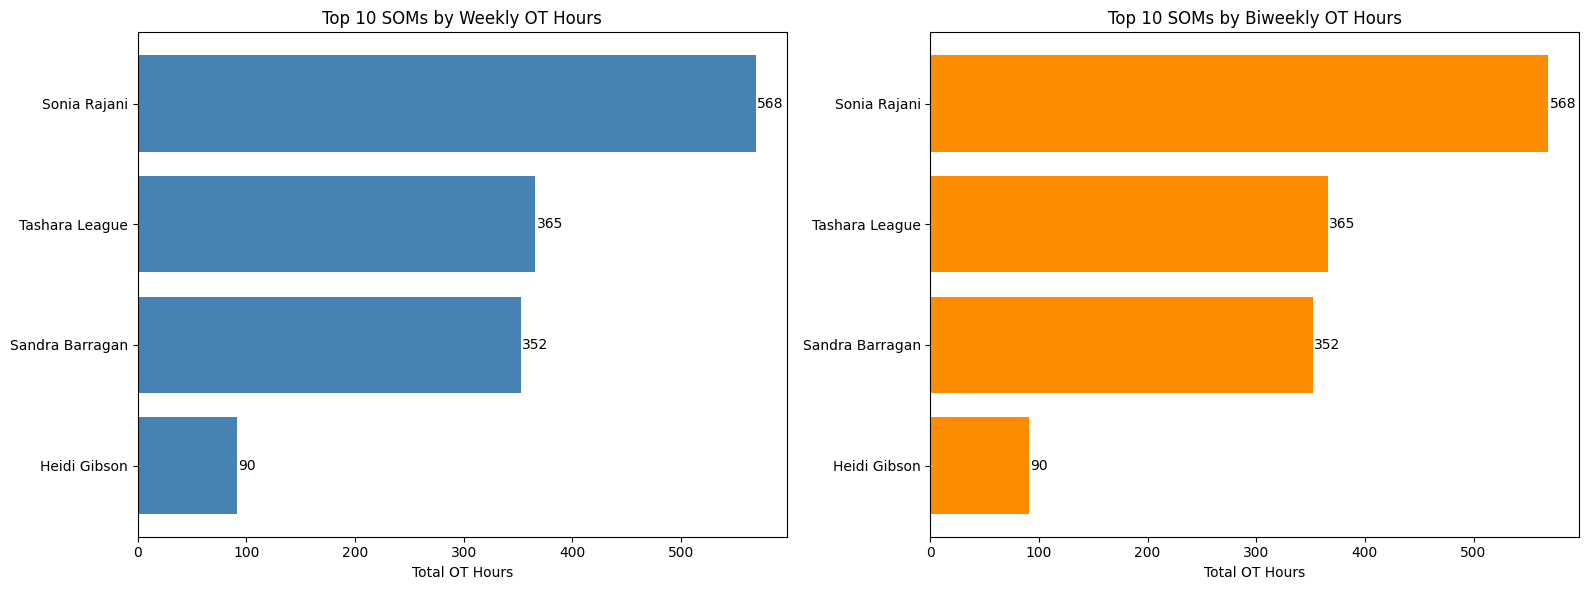

Charts saved to output_data/ot_hours_by_som_charts.png


In [13]:
# Add some visualizations
import matplotlib.pyplot as plt

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Weekly OT Hours by SOM (top 10)
ot_by_som_pivot_without_total = ot_by_som_pivot.drop("Total_OT_Hours", axis=1, errors="ignore")
weekly_totals = ot_by_som_pivot_without_total.sum(axis=1).sort_values(ascending=False).head(10)
axes[0].barh(weekly_totals.index, weekly_totals.values, color='steelblue')
axes[0].set_xlabel('Total OT Hours')
axes[0].set_title('Top 10 SOMs by Weekly OT Hours')
axes[0].invert_yaxis()
for i, v in enumerate(weekly_totals.values):
    axes[0].text(v + 1, i, str(int(v)), va='center')

# Plot 2: Biweekly OT Hours by SOM (top 10)
ot_by_som_biweekly_pivot_without_total = ot_by_som_biweekly_pivot.drop("Total_OT_Hours", axis=1, errors="ignore")
biweekly_totals = ot_by_som_biweekly_pivot_without_total.sum(axis=1).sort_values(ascending=False).head(10)
axes[1].barh(biweekly_totals.index, biweekly_totals.values, color='darkorange')
axes[1].set_xlabel('Total OT Hours')
axes[1].set_title('Top 10 SOMs by Biweekly OT Hours')
axes[1].invert_yaxis()
for i, v in enumerate(biweekly_totals.values):
    axes[1].text(v + 1, i, str(int(v)), va='center')

plt.tight_layout()
plt.savefig("output_data/ot_hours_by_som_charts.png", dpi=150, bbox_inches='tight')
plt.show()

print("Charts saved to output_data/ot_hours_by_som_charts.png")